In [ ]:
## necessary imports 
import numpy as np  # for performing arithmatic logic
import pandas as pd #for manipluting and preprocessing dataframes
import seaborn as sns #seaborn along side with matplotlib for data visualisation
import matplotlib.pyplot as plt
from warnings import filterwarnings # for ignoring unnecessary warnings
filterwarnings('ignore')

### Customer dataset ingestion

In [ ]:

## we will take 'Telco Customer Churn' by BLASTCHAR from KAGGLE website as .csv file


df =  pd.read_csv('../../dataset/Telco-Customer-Churn.csv') # path for .csv file
df.head() # data is sucesfully imported

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data cleaning and preprocessing

In [ ]:
# We will start by understaqnding data

df.shape #the Shape of data (7043, 21)

# df.info()
#data Consists of 21 column with dtypes: float64(1), int64(2), object(18)

(7043, 21)

In [ ]:
# checking for null/ na values in dataset

df.isnull().sum() # there are no null entries in dataset
df.isna().sum() # there are no NA entries in dataset


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
# as we can see customer doesnt seem relevant to our objective 
# so we will drop it 
df = df.drop(columns=['customerID'], axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# describing the dataset
df.describe() 

# SeniorCeitizen representing 1=true, 0=false for being senior citizen
# tenure representing the years the person have been suscribing to the service
# monthly charges being the charges according to the month
# ans TotalCharhges representing total charges in total 

# as we can see the data have 3 numerical fields 
# but the in data senior ceitizen column is represented as true or false so we cannot consider as a numerical field
# and column TotalCharges datatype is of string where as inserted is of float 
# so we will convert it to float 

#before converting we will check for whitespace string s ' '

df[df['TotalCharges'] == ' '] 

# we can see there are several entries with total charge blank but also the trenure being 0 that means the customer didnt take the subscription for long enough
# we will replace them with 0 for more accuracy

df['TotalCharges'] = df['TotalCharges'].replace({" " :0.0})
df[df['TotalCharges'] == ' '].count()

# now there are no more blank entries
# changing type from object to float

df['TotalCharges'] = df['TotalCharges'].astype(float)
df.info() # for chhecking datatype conversion 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
# now we will check for unique values in non numeric coulmns
columns = ['tenure','MonthlyCharges','TotalCharges'] # list of numeric columns

for col in df.columns:
    if col not in columns:
        print(col, df[col].unique())
        print('-'*50)

# here we can see come columns contains strings like male/female such as gender and contract will and    
# mostly fields contain yes/no and boolean values but some fiels such as MultipleLines, InternetService, OnlineSecurity 
#contains an extra entry for same purpose here No & No phone/ No internet service results same 
# we will replace them 



gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV ['No' 'Yes' 'No internet 

In [ ]:
df['MultipleLines'].replace('No phone service', 'No', inplace=True)
df['OnlineSecurity'].replace('No internet service', 'No', inplace=True)
df['OnlineBackup'].replace('No internet service', 'No', inplace=True)
df['DeviceProtection'].replace('No internet service', 'No', inplace=True)
df['TechSupport'].replace('No internet service', 'No', inplace=True)
df['StreamingTV'].replace('No internet service', 'No', inplace=True)
df['StreamingMovies'].replace('No internet service', 'No', inplace=True)

columns = ['tenure','MonthlyCharges','TotalCharges'] # list of numeric columns

for col in df.columns:
    if col not in columns:
        print(col, df[col].unique())
        print('-'*50)

gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes']
--------------------------------------------------
OnlineBackup ['Yes' 'No']
--------------------------------------------------
DeviceProtection ['No' 'Yes']
--------------------------------------------------
TechSupport ['No' 'Yes']
--------------------------------------------------
StreamingTV ['No' 'Yes']
--------------------------------------------------
StreamingMovies ['No' 'Yes']
---------------------------------------

In [ ]:
# describe the dataset
df.describe()

# there maximum & minimum of customers tenure : 72 & 0 || avg : 32
# there maximum & minimum of customers MonthlyCharges : 118.750000 & 18.250000 || avg : 64.761692
# there maximum & minimum of customers TotalCharges : 8684.800000 & 0.0 || avg : 2279.734304

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


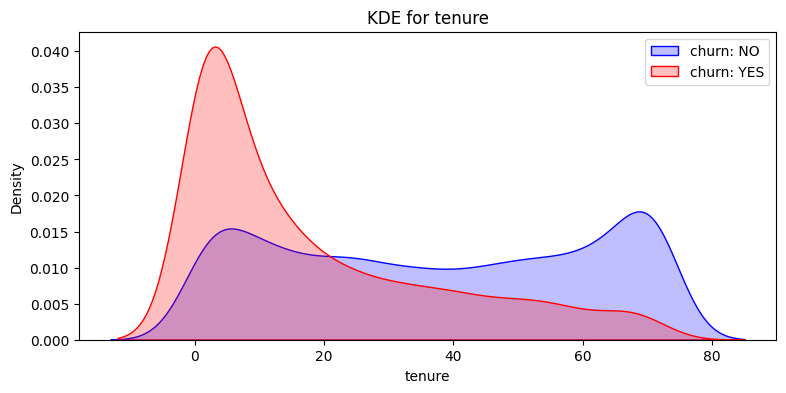

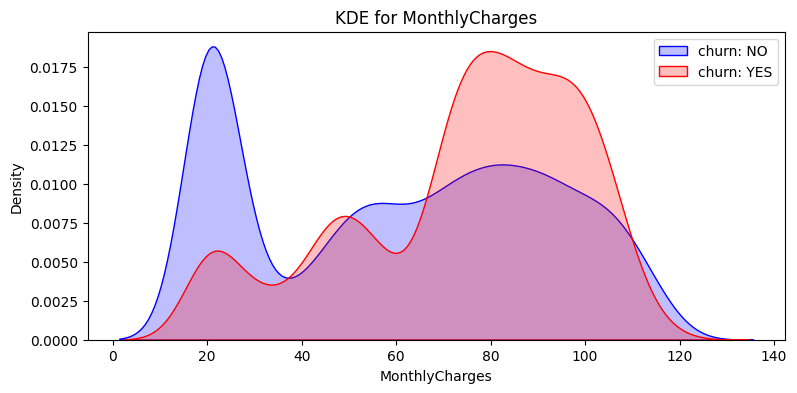

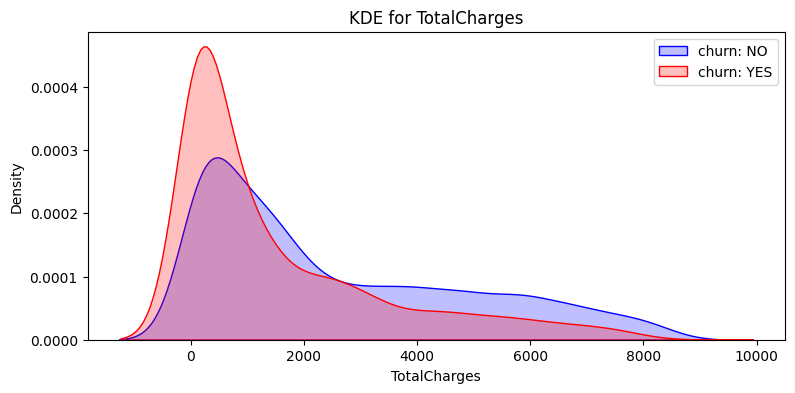

In [ ]:


def kdplot(feature):
    plt.figure(figsize=(9,4))
    plt.title(f"KDE for {feature}")

    ax0 = sns.kdeplot(df[df['Churn'] == 'No'][feature].dropna(), color='blue', label='churn: NO', fill=True)
    ax0 = sns.kdeplot(df[df['Churn'] == 'Yes'][feature].dropna(), color='red', label='churn: YES', fill=True)

    plt.legend()
    plt.show()

kdplot('tenure')
kdplot('MonthlyCharges')
kdplot('TotalCharges')



# density plot for tenure with churn

#  Highest number of Customers have churned in the initial 20 years
# customers over 20-40 years are less likely to churn
# Customer over 40 years are continuing the service
 

# density plot for Monthly Charges with churn

# highest number of people churned when the charges between 60$ - 120$
# chart peeked between 0$ to 40$ where customer wernt churning 
# customer churning increased as the rates grew higher

# density plot for Total Charges with churn

# chart peaked with less people churning at total amount less than 2000$(half)
# half of the Customers churned while the amount where less than 4000$
# customers kept churning as the amount increased but people churning kept decreasing

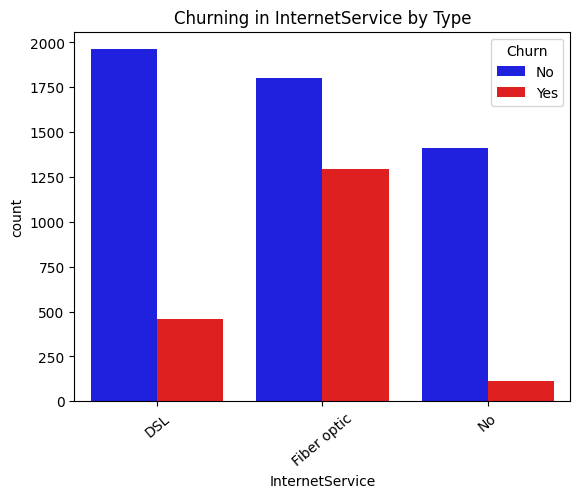

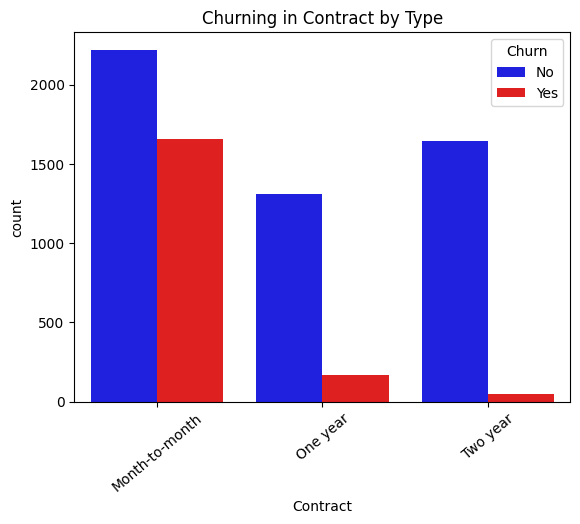

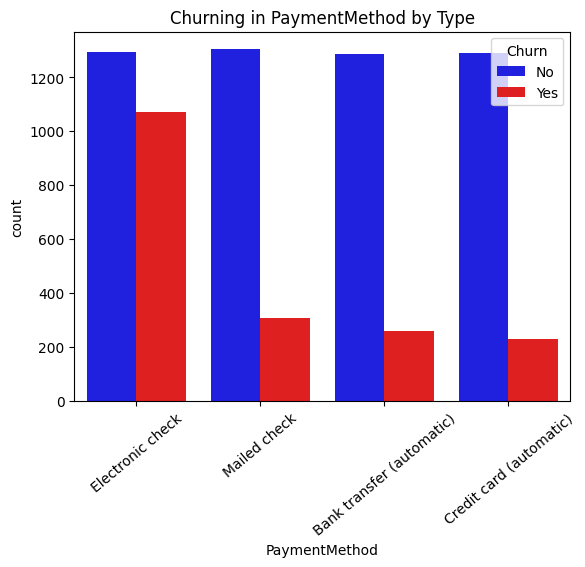

In [ ]:

# Performing EDA on categorical fields with respect to Churn 
categ_cols = ['InternetService','Contract','PaymentMethod']    
# df.info()
for i in categ_cols:
    plt.Figure(figsize=(10,10))
    sns.countplot(x=i, hue='Churn', data=df, palette=['blue', 'red'])
    plt.title(f"Churning in {i} by Type")
    plt.xticks(rotation=40)
    plt.show()



# InternetService

# large numbers of customer have churned of fiber optic category and less which do not have internet service
# around 250 to 500 customers have churned in DSL category less than fiber optic and greater than NO serrvice

#Cantract type

# large number of Customers around 1500 to 2000 have churned in month to month category 
# lesser in 1 year category ranging upto 500 and least in 2 year

# Payment method

#large number of customers have churnned in range of 10000 to 12000 in Eletronic Check category and rest categories have churning little over 200 and less than 300

### Customer segmentation analysis


In [ ]:
# now we will create segments for numerical columns like tenure, MonthlyCharges & TotalCharges

df['tenure_segment'] = pd.cut(
    df['tenure'],
    bins=[-1,12,24,48,72],
    labels=['new','short-term','mid-term', 'loyal']
) # tenure segment will map the entries with labels and make it efficient for classification

df['Charges_segment'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0,40,80,120],
    labels=['low', 'medium', 'high'] 
)# monthlyCharges_segments will map the entries with labels and make it efficient for classification


 ### Identification of behavior patterns

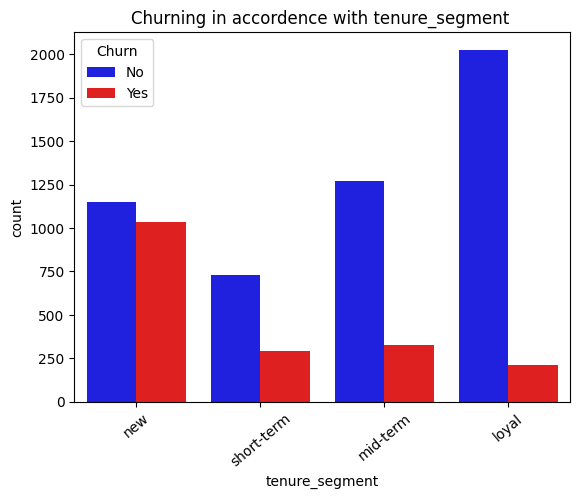

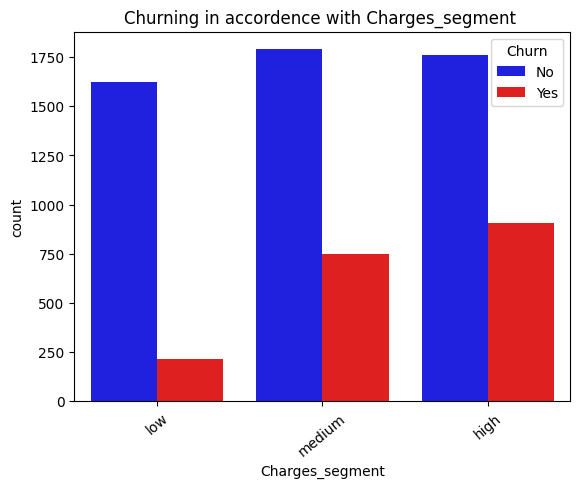

In [ ]:


categ_cols = ['tenure_segment','Charges_segment']    
# df.info()
for i in categ_cols:
    plt.Figure(figsize=(10,10))
    sns.countplot(x=i, hue='Churn', data=df, palette=['blue', 'red'])
    plt.title(f"Churning in accordence with {i} ")
    plt.xticks(rotation=40)
    plt.show()

In [ ]:
df.groupby('tenure_segment')['Churn'].mean()

# tenure segment shows customer behaviour such as new customer are more likely to churn

tenure_segment
new           0.474382
short-term    0.287109
mid-term      0.203890
loyal         0.095132
Name: Churn, dtype: float64

In [ ]:
df.groupby('Charges_segment')['Churn'].mean()


#Charges segment shows customer behaviour such as higher amount customer are more likely to churn  

Charges_segment
low       0.116431
medium    0.294998
high      0.339835
Name: Churn, dtype: float64

### Basic predictive analysis for churn or purchase intent ###
(Logistic regression for classification)

In [ ]:
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})

In [ ]:
df2 = pd.get_dummies(data=df, columns=df.select_dtypes(exclude=[np.number]).columns, dtype=int)


In [ ]:
# now we will scale the remaining features to make it efficeient for the model
# we will use minMax scaller

cols_to_scale = ['tenure', 'MonthlyCharges','TotalCharges']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()


df2[cols_to_scale] = scaler.fit_transform(df2[cols_to_scale])


In [ ]:
for col in df2:
    print(f'{col}:{df2[col].unique()}')
    print('-'*50)


SeniorCitizen:[0 1]
--------------------------------------------------
tenure:[0.01388889 0.47222222 0.02777778 0.625      0.11111111 0.30555556
 0.13888889 0.38888889 0.86111111 0.18055556 0.22222222 0.80555556
 0.68055556 0.34722222 0.95833333 0.72222222 0.98611111 0.29166667
 0.16666667 0.41666667 0.65277778 1.         0.23611111 0.375
 0.06944444 0.63888889 0.15277778 0.97222222 0.875      0.59722222
 0.20833333 0.83333333 0.25       0.91666667 0.125      0.04166667
 0.43055556 0.69444444 0.88888889 0.77777778 0.09722222 0.58333333
 0.48611111 0.66666667 0.40277778 0.90277778 0.52777778 0.94444444
 0.44444444 0.76388889 0.51388889 0.5        0.56944444 0.08333333
 0.05555556 0.45833333 0.93055556 0.31944444 0.79166667 0.84722222
 0.19444444 0.27777778 0.73611111 0.55555556 0.81944444 0.33333333
 0.61111111 0.26388889 0.75       0.70833333 0.36111111 0.
 0.54166667]
--------------------------------------------------
MonthlyCharges:[0.11542289 0.38507463 0.35422886 ... 0.44626866 0.2

In [ ]:
X = df2.drop(columns=['Churn'])
Y = df2['Churn']




In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

x_train, x_test, y_train,y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

y_train.value_counts()


Churn
0    4138
1    1496
Name: count, dtype: int64

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)


x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [ ]:
model = LogisticRegression()
model.fit(x_train_smote, y_train_smote)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
model.score(x_test, y_test)

0.8090844570617459

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.86      0.87      1036
           1       0.63      0.66      0.65       373

    accuracy                           0.81      1409
   macro avg       0.75      0.76      0.76      1409
weighted avg       0.81      0.81      0.81      1409



### Visualization of key insights

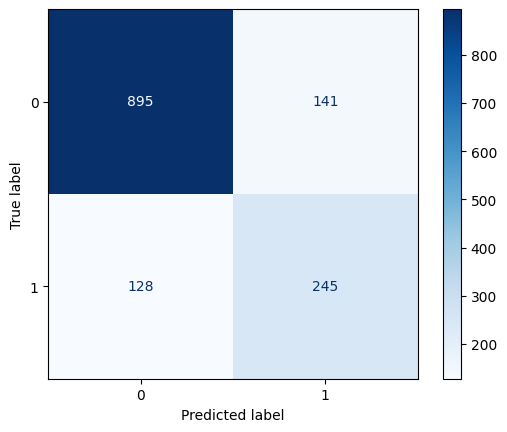

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")

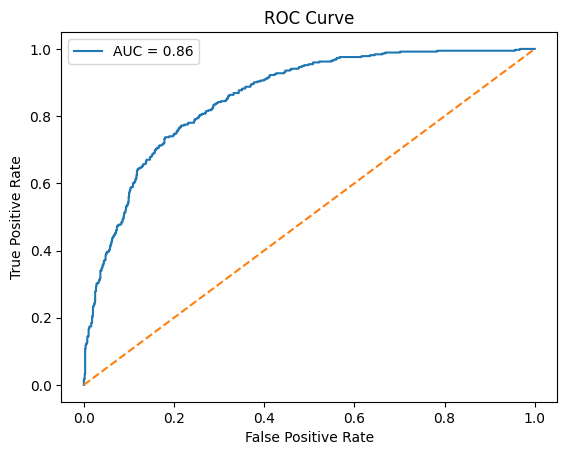

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# get probability of churn
y_prob = model.predict_proba(x_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')  # random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

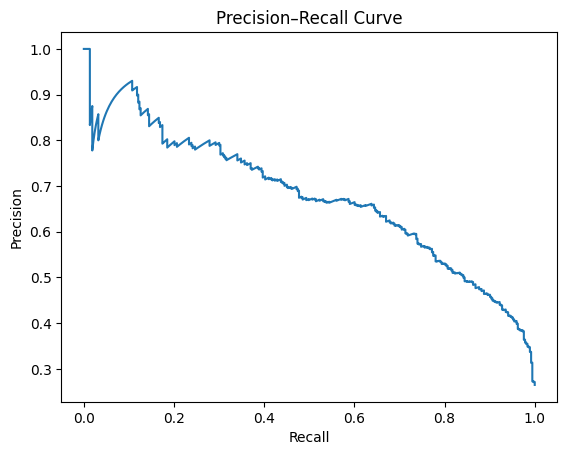

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

###  Business-focused insight report